In [ ]:
#1-2-2026
#qg/qg+qs
#with derivatives
#threshold = 5e-12
#Mass-weighted random sampling
# start_time = 1979-01-12T00:00:00 
# end_time = 1979-01-12T00:00:00 

import time
overall_start_time = time.time()
import os

import importlib
import sys

# #Remove cached modules
# for module_name in list(sys.modules.keys()):
#     if 'dataset_init' in module_name:
#         del sys.modules[module_name]

# #Reimport
# from Tools import dataset_init

import numpy as np
import pandas as pd
#%matplotlib inline  #won't work for .py
import matplotlib.pyplot as plt
import xarray as xr

# import json_file_editer as JFE
from File_management import json_file_editer as JFE
from Calculation import job_manager 
from Tools import dataset_init
from Log_management import Log

import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

#random forest
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')

#ISLP
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS

from sklearn.tree import (DecisionTreeClassifier as DTC,
 DecisionTreeRegressor as DTR,
 plot_tree,
 export_text)
from sklearn.metrics import (accuracy_score,
 log_loss)
from sklearn.ensemble import \
 (RandomForestRegressor as RF,
 GradientBoostingRegressor as GBR)
from ISLP.bart import BART

#################################################################
Log.init_log(os.path.join('./output'), filename=f"Log_ML.txt")
Log.add_to_log("Log nicely initialized ")

options_json=JFE.get_json_data("options.json")
options_json["Header"]["status"]
chunks = {}
myJob = job_manager.JobManager(options_json)
ds = dataset_init.ds_init_3d(myJob, chunks={}) 

The job folder path : ./output/Log_ML.txt
2026 Feb 02 13:35:15 > Log nicely initialized 
2026 Feb 02 13:35:15 > (DI0010) making data from P-O files requires small differences in the code, hardly automisable.
2026 Feb 02 13:35:15 > (DI0020) Starting PO dataset creation from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim_19-01-2026/build_16-01-2025/experiments/pod0001
2026 Feb 02 13:35:15 > (DI0021) Found 8 time-varying files in date range
2026 Feb 02 13:35:16 > (DI0022) Loading vertical grid data from /work/mh0066/m301130/projects/scheme_comparison/icon-mpim_19-01-2026/build_16-01-2025/experiments/pod0001/pod0001_atm_vgrid_ml.nc
2026 Feb 02 13:35:16 > (DI0023) Grid variables available: ['clon_bnds', 'clat_bnds', 'height_bnds', 'height_2_bnds', 'zghalf', 'zg', 'dzghalf', 'clon', 'clat', 'height', 'height_2']
2026 Feb 02 13:35:16 > (DI0024) Dimensions in vgrid: FrozenMappingWarningOnValuesAccess({'ncells': 20971520, 'vertices': 3, 'height': 60, 'bnds': 2, 'height_2': 60})
2026 

In [60]:
ds

<xarray.Dataset> Size: 78GB
Dimensions:    (ncells: 20971520, time: 1, height: 61, height_2: 61)
Coordinates:
  * time       (time) datetime64[ns] 8B 1979-01-12
  * height     (height) float64 488B 2.0 31.0 32.0 33.0 ... 87.0 88.0 89.0 90.0
  * height_2   (height_2) float64 488B 10.0 31.0 32.0 33.0 ... 88.0 89.0 90.0
    clon       (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
    clat       (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
Dimensions without coordinates: ncells
Data variables: (12/22)
    cell_area  (ncells) float64 168MB dask.array<chunksize=(20971520,), meta=np.ndarray>
    pr         (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    tas        (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    clivi      (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    cllvi      (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    qgvi       (time, ncells) float32 84MB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    ...         ...
    rho        (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    dzghalf    (height, ncells) float32 5GB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    zg         (height_2, ncells) float32 5GB dask.array<chunksize=(1, 3497984), meta=np.ndarray>
    ua         (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    va         (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
    pfull      (time, height, ncells) float32 5GB dask.array<chunksize=(1, 1, 3497984), meta=np.ndarray>
Attributes: (12/46)
    CDI:                      Climate Data Interface version 2.5.2.1 (https:/...
    Conventions:              CF-1.6
    number_of_grid_used:      55
    grid_file_uri:            http://icon-downloads.mpimet.mpg.de/grids/publi...
    uuidOfHGrid:              9a8d03ba-2027-11ef-a2ba-c74e1b4d7fe9
    institution:              Max Planck Institute for Meteorology/Deutscher ...
    ...                       ...
    topography:               modified SRTM30
    symmetry:                 along equator
    subcentre:                0
    ICON_grid_file_uri:       http://icon-downloads.mpimet.mpg.de/grids/publi...
    optimization:             spring dynamics
    NCO:                      netCDF Operators version 5.0.6 (Homepage = http...

In [61]:
#RH from SH
def RH_from_SH(pfull, hus, ta, T_0= 273.16):
    RH = 0.26 * pfull * hus / np.exp(17.67 * (ta - T_0) / (ta - 29.65))
    return RH

In [62]:
# ds['zg']
#print(ds['zg'][height2_index,cell_index])
#print(ds['zg'][60,555].values)

In [63]:
#Values for hus, pfull and ta above the current cell
height_range = range(31, 91, 1)

#Create a list to store datasets for each height level
ds_list = []

for ht in height_range:
    #Select where BOTH height and height_2 equal the same value
    ds_ht = ds.sel(height=ht, height_2=ht)
    ds_list.append(ds_ht)

#Concatenate along the height dimension
ds_subset = xr.concat(ds_list, dim='height')

#EXTRACT hus VALUES FROM ABOVE
hus_above = ds_subset['hus'].shift(height=1)

#Handle boundary conditions
hus_above = hus_above.fillna(ds_subset['hus']) 

#Add to dataset
ds_subset['hus_above'] = hus_above

#EXTRACT ta VALUES FROM ABOVE
ta_above = ds_subset['ta'].shift(height=1)
ta_above = ta_above.fillna(ds_subset['ta'])
ds_subset['ta_above'] = ta_above

#EXTRACT wa VALUES FROM ABOVE
wa_above = ds_subset['wa'].shift(height=1)
wa_above = wa_above.fillna(ds_subset['wa'])
ds_subset['wa_above'] = wa_above

#EXTRACT pfull VALUES FROM ABOVE
pfull_above = ds_subset['pfull'].shift(height=1)
pfull_above = pfull_above.fillna(ds_subset['pfull'])
ds_subset['pfull_above'] = pfull_above

#EXTRACT RH VALUES FROM ABOVE
ds_subset['RH']=RH_from_SH(ds_subset['pfull'], ds_subset['hus'], ds_subset['ta'])
ds_subset['RH_above']=RH_from_SH(ds_subset['pfull_above'], ds_subset['hus_above'], ds_subset['ta_above'])
ds_subset["RH_above"] = ds_subset["RH_above"].fillna(ds_subset["RH"]) #remove this step?

#EXTRACT zg VALUES FROM ABOVE
zg_above = ds_subset["zg"].shift(height=1)
zg_above = zg_above.fillna(ds_subset["zg"])
ds_subset["zg_above"] = zg_above

#Check
# if (
#     (ds_subset.sel(height=89)["zg_above"] == ds_subset.sel(height=88)["zg"]).all()
# ):
#     print("All assertions passed for zg!")
# else:
#     print("Assertion failed for zg!")

In [64]:
ds_subset['clw+cli'] = ds_subset['clw'] + ds_subset['cli']
clw_cli_above = ds_subset['clw+cli'].shift(height=1)
clw_cli_above = clw_cli_above.fillna(ds_subset['clw+cli'])
ds_subset['clw+cli_above'] = clw_cli_above

In [65]:
#del_clw+cli/del_z
ds_subset['del_clw+cli/del_z']= ( ( ds_subset['clw+cli_above'] - ds_subset['clw+cli'] ) / ( ds_subset['zg_above'] - ds_subset['zg'] ) )

ds_subset['del_clw+cli/del_z'] = ds_subset['del_clw+cli/del_z'].where(
    ds_subset['zg_above'] != ds_subset['zg'],
    ds_subset['del_clw+cli/del_z'].shift(height=-1)
)

In [66]:
# ds_subset['cllvi+clivi'] = ds_subset['cllvi'] + ds_subset['clivi']
# cllvi_clivi_above = ds_subset['cllvi+clivi'].shift(height=1)
# cllvi_clivi_above = cllvi_clivi_above.fillna(ds_subset['cllvi+clivi'])
# ds_subset['cllvi+clivi_above'] = cllvi_clivi_above

In [67]:
# #del_cllvi+clivi/del_z
# ds_subset['del_cllvi+clivi/del_z']= ( ( ds_subset['cllvi+clivi_above'] - ds_subset['cllvi+clivi'] ) / ( ds_subset['zg_above'] - ds_subset['zg'] ) )

# ds_subset['del_cllvi+clivi/del_z'] = ds_subset['del_cllvi+clivi/del_z'].where(
#     ds_subset['zg_above'] != ds_subset['zg'],
#     ds_subset['del_cllvi+clivi/del_z'].shift(height=-1)
# )

In [68]:
# # Select the first grid cell (first clat, clon)
# first_cell_idx = 0

# # Extract clat and clon for this cell
# clat_value = ds['clat'].isel(ncells=first_cell_idx).values
# clon_value = ds['clon'].isel(ncells=first_cell_idx).values

# print(f"Selected location:")
# print(f"  Latitude: {clat_value:.3f}°")
# print(f"  Longitude: {clon_value:.3f}°")

# # Extract cllvi values for this cell across all heights
# # Note: cllvi is typically a column-integrated quantity, but if it varies with height in your data:
# cllvi_profile = ds['cllvi'].isel(ncells=first_cell_idx).values

# # Get height values
# height_values = ds['height'].values

# # Create publication-quality figure
# fig, ax = plt.subplots(figsize=(8, 10))

# # Plot vertical profile
# ax.plot(cllvi_profile, height_values, 'o-', linewidth=2, markersize=6, 
#         color='#2E86AB', markerfacecolor='white', markeredgewidth=2, 
#         markeredgecolor='#2E86AB', label='CLLVI')

# # Formatting
# ax.set_xlabel('Cloud Liquid Water Path (kg m$^{-2}$)', fontsize=14, fontweight='bold')
# ax.set_ylabel('Height Level', fontsize=14, fontweight='bold')
# ax.set_title(f'Vertical Profile of Cloud Liquid Water Path\n' + 
#              f'Location: {clat_value:.2f}°N, {clon_value:.2f}°E',
#              fontsize=15, fontweight='bold', pad=20)

# # Grid
# ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
# ax.set_axisbelow(True)

# # Tick parameters
# ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
# ax.tick_params(axis='both', which='minor', width=1, length=3)

# # Spine formatting
# for spine in ax.spines.values():
#     spine.set_linewidth(1.5)

# # Add zero reference line if data crosses zero
# if cllvi_profile.min() < 0:
#     ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

# # Set x-axis to start at 0 if all values are positive
# if cllvi_profile.min() >= 0:
#     ax.set_xlim(left=0)

# # Legend
# ax.legend(loc='best', fontsize=12, framealpha=0.9, edgecolor='black')

# # Tight layout
# plt.tight_layout()

# # Save figure
# plt.savefig('cllvi_vertical_profile.png', dpi=300, bbox_inches='tight', facecolor='white')
# plt.savefig('cllvi_vertical_profile.pdf', bbox_inches='tight', facecolor='white')

# plt.show()

# # Print summary statistics
# print(f"\nCLLVI Statistics at this location:")
# print(f"  Minimum: {cllvi_profile.min():.6e} kg m⁻²")
# print(f"  Maximum: {cllvi_profile.max():.6e} kg m⁻²")
# print(f"  Mean: {cllvi_profile.mean():.6e} kg m⁻²")
# print(f"  Std Dev: {cllvi_profile.std():.6e} kg m⁻²")

In [69]:
ds_subset['qr+qg+qs']=ds_subset['qr']+ds_subset['qg']+ds_subset['qs']
qr_qg_qs_above = ds_subset['qr+qg+qs'].shift(height=1)
qr_qg_qs_above = qr_qg_qs_above.fillna(ds_subset['qr+qg+qs'])
ds_subset['qr+qg+qs_above']=qr_qg_qs_above

In [70]:
#del_qr+qg+qs/del_z
ds_subset['del_qr+qg+qs/del_z']= ( ( ds_subset['qr+qg+qs_above'] - ds_subset['qr+qg+qs'] ) / ( ds_subset['zg_above'] - ds_subset['zg'] ) )

ds_subset['del_qr+qg+qs/del_z'] = ds_subset['del_qr+qg+qs/del_z'].where(
    ds_subset['zg_above'] != ds_subset['zg'],
    ds_subset['del_qr+qg+qs/del_z'].shift(height=-1)
)

In [71]:
#del_RH/del_z
# ds_subset['del_RH/del_z']= 0.5 * ( ( ( ds_subset['RH_above'] - ds_subset['RH'] ) / ( ds_subset['dzghalf_above'] - ds_subset['dzghalf'] ) ) + ( ( ds_subset['RH'] - ds_subset['RH_below'] ) / ( ds_subset['dzghalf'] - ds_subset['dzghalf_below'] ) )  )

#del_RH/del_z
ds_subset['del_RH/del_z']= ( ( ds_subset['RH_above'] - ds_subset['RH'] ) / ( ds_subset['zg_above'] - ds_subset['zg'] ) )

ds_subset['del_RH/del_z'] = ds_subset['del_RH/del_z'].where(
    ds_subset['zg_above'] != ds_subset['zg'],
    ds_subset['del_RH/del_z'].shift(height=-1)
)
# ds_subset

In [72]:
#del_hus/del_z
ds_subset['del_hus/del_z']= ( ( ds_subset['hus_above'] - ds_subset['hus'] ) / ( ds_subset['zg_above'] - ds_subset['zg'] ) )

ds_subset['del_hus/del_z'] = ds_subset['del_hus/del_z'].where(
    ds_subset['zg_above'] != ds_subset['zg'],
    ds_subset['del_hus/del_z'].shift(height=-1)
)

In [73]:
#del_ta/del_z
ds_subset['del_ta/del_z']= ( ( ds_subset['ta_above'] - ds_subset['ta'] ) / ( ds_subset['zg_above'] - ds_subset['zg'] ) )

ds_subset['del_ta/del_z'] = ds_subset['del_ta/del_z'].where(
    ds_subset['zg_above'] != ds_subset['zg'],
    ds_subset['del_ta/del_z'].shift(height=-1)
)

In [74]:
#del_pfull/del_z
ds_subset['del_pfull/del_z']= ( ( ds_subset['pfull_above'] - ds_subset['pfull'] ) / ( ds_subset['zg_above'] - ds_subset['zg'] ) )

ds_subset['del_pfull/del_z'] = ds_subset['del_pfull/del_z'].where(
    ds_subset['zg_above'] != ds_subset['zg'],
    ds_subset['del_pfull/del_z'].shift(height=-1)
)

In [75]:
#del_wa/del_z
ds_subset['del_wa/del_z']= ( ( ds_subset['wa_above'] - ds_subset['wa'] ) / ( ds_subset['zg_above'] - ds_subset['zg'] ) )

ds_subset['del_wa/del_z'] = ds_subset['del_wa/del_z'].where(
    ds_subset['zg_above'] != ds_subset['zg'],
    ds_subset['del_wa/del_z'].shift(height=-1)
)

In [76]:
# #Derivative operations on a sample pandas df

# kotha_df=pd.DataFrame({"height": [1,2,3],
#                        "RH": [1,2,3],
#                        "RH_above": [1,1,2],
#                        "zg": [4,5,6], 
#                        "zg_above": [4,4,5]})
# print(kotha_df)

# #del_RH/del_z
# kotha_df['del_RH/del_z']= ( ( kotha_df['RH_above'] - kotha_df['RH'] ) / ( kotha_df['zg_above'] - kotha_df['zg'] ) )
# print(kotha_df)

# #Either do the following or slice the first row from the dataframe.

# kotha_df['del_RH/del_z'] = kotha_df['del_RH/del_z'].where(
#     kotha_df['zg_above'] != kotha_df['zg'],
#     kotha_df['del_RH/del_z'].shift(-1)
# )
# print(kotha_df)

In [77]:
# #Derivative operations on a sample xarray ds

# kotha_ds = xr.Dataset(
#     {
#         "RH": ("height", [1, 2, 3]),
#         "RH_above": ("height", [1, 1, 2]),
#         "zg": ("height", [4, 5, 6]),
#         "zg_above": ("height", [4, 4, 5])
#     },
#     coords={"height": [0, 1, 2]}  # index-like heights
# )
# print("Original dataset:\n", kotha_ds)

# #Derivative
# kotha_ds["del_RH/del_z"] = (kotha_ds["RH_above"] - kotha_ds["RH"]) / (kotha_ds["zg_above"] - kotha_ds["zg"])
# print("\nAfter calculating del_RH/del_z:\n", kotha_ds)

# #Replace values where zg_above == zg with the value from the cell below
# kotha_ds["del_RH/del_z"] = kotha_ds["del_RH/del_z"].where(
#     kotha_ds["zg_above"] != kotha_ds["zg"],
#     kotha_ds["del_RH/del_z"].shift(height=-1)
# )

# print("\nAfter applying the replacement:\n", kotha_ds)

In [78]:
#Calculate condensate and precipitate fractions
total = ds_subset['clw'] + ds_subset['cli']
ds_subset['clw/(clw+cli)'] = ds_subset['clw'].where(total != 0, 0) / total.where(total != 0, 1)
ds_subset['cli/(clw+cli)'] = ds_subset['cli'].where(total != 0, 0) / total.where(total != 0, 1)

total_precipitates = ds_subset['qr'] + ds_subset['qs'] + ds_subset['qg']
ds_subset['qr/(qr+qs+qg)'] = ds_subset['qr'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
ds_subset['qs/(qr+qs+qg)'] = ds_subset['qs'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)
ds_subset['qg/(qr+qs+qg)'] = ds_subset['qg'].where(total_precipitates != 0, 0) / total_precipitates.where(total_precipitates != 0, 1)

In [79]:
#CONVERT TO DATAFRAME

# First, filter ds_subset to only include the desired height levels
# height_range_filtered = range(31, 91, 5)  # 31, 36, 41, 46, 51, 56, 61, 66, 71, 76, 81, 86
height_range_filtered = range(31, 91, 5)  

# Select only these height levels from ds_subset
ds_subset_filtered = ds_subset.sel(height=list(height_range_filtered))

# # Now convert to dataframe
# df = ds_subset_filtered.to_dataframe().reset_index() #This line could probably lead to the kernel crash

In [80]:
#Alternative-1
# Process one height level at a time
df_list = []

for ht in height_range_filtered:
    print(f"Processing height level {ht}...")
    
    # Select single height level
    ds_single = ds_subset_filtered.sel(height=ht)
    
    # Convert just this height level to dataframe
    df_single = ds_single.to_dataframe().reset_index()
    
    df_list.append(df_single)
    
    # Optional: clear memory
    del ds_single

# Concatenate all height levels
df = pd.concat(df_list, ignore_index=True)
del df_list  # Free memory

print(f"Final dataframe shape: {df.shape}")
print(f"Expected rows (if no missing data): {len(height_range_filtered) * ds['ncells'].size}") #check

# Verify height == height_2 for all rows
print(f"\nRows where height != height_2: {(df['height'] != df['height_2']).sum()}")

# Verify we only have the desired height levels
print(f"\nUnique height values in df: {sorted(df['height'].unique())}")

print("\nSample of hus values:")
print(df[['height', 'height_2', 'clat', 'clon', 'hus', 'hus_above']].head(15))

# Check for duplicates
duplicates = df.duplicated(subset=['clat', 'clon', 'height']).sum()
print(f"\nNumber of duplicate (clat, clon, height) combinations: {duplicates}")

# Check for NaN values in hus (not hus_above/below)
print(f"\nNaN count in original hus: {df['hus'].isna().sum()}")
print(f"NaN count in hus_above: {df['hus_above'].isna().sum()}")

Processing height level 31...
Processing height level 36...
Processing height level 41...
Processing height level 46...
Processing height level 51...
Processing height level 56...
Processing height level 61...
Processing height level 66...
Processing height level 71...
Processing height level 76...
Processing height level 81...
Processing height level 86...
Final dataframe shape: (251658240, 51)
Expected rows (if no missing data): 251658240

Rows where height != height_2: 0

Unique height values in df: [np.float64(31.0), np.float64(36.0), np.float64(41.0), np.float64(46.0), np.float64(51.0), np.float64(56.0), np.float64(61.0), np.float64(66.0), np.float64(71.0), np.float64(76.0), np.float64(81.0), np.float64(86.0)]

Sample of hus values:
    height  height_2      clat      clon       hus  hus_above
0     31.0      31.0  0.918163  1.274090  0.000003   0.000003
1     31.0      31.0  0.918508  1.275076  0.000003   0.000003
2     31.0      31.0  0.918508  1.273105  0.000003   0.000003
3   

In [81]:
# #Alternative-2
# # Convert to dask dataframe
# ds_subset_filtered = ds_subset_filtered.unify_chunks()
# df_dask = ds_subset_filtered.to_dask_dataframe()

# print(df_dask.describe().compute())

# from dask.diagnostics import ProgressBar
# with ProgressBar():
#     df = df_dask.compute()

In [82]:
# print(f"Final dataframe shape: {df.shape}")
# print(f"Expected rows (if no missing data): {len(height_range_filtered) * ds['ncells'].size}") #check

# # Verify height == height_2 for all rows
# print(f"\nRows where height != height_2: {(df['height'] != df['height_2']).sum()}")

# # Verify we only have the desired height levels
# print(f"\nUnique height values in df: {sorted(df['height'].unique())}")

# print("\nSample of hus values:")
# print(df[['height', 'height_2', 'clat', 'clon', 'hus', 'hus_above']].head(15))

# # Check for duplicates
# duplicates = df.duplicated(subset=['clat', 'clon', 'height']).sum()
# print(f"\nNumber of duplicate (clat, clon, height) combinations: {duplicates}")

# # Check for NaN values in hus (not hus_above/below)
# print(f"\nNaN count in original hus: {df['hus'].isna().sum()}")
# print(f"NaN count in hus_above: {df['hus_above'].isna().sum()}")

In [83]:
old_df_len = len(df)
print("Length of the old df: ", old_df_len)
threshold = 5e-12
df_new = df[(df['cli'] + df['clw'] + df['qr'] + df['qg'] + df['qs']) >= threshold]
# print('df- After threshold-1:')
# print(df_new)
if df_new.empty:
    df_new = df

df = df_new
new_df_len = len(df)
# print('df after threshold-2:\n', df)
print("Length of the new df: ", new_df_len)
percent_data_removed=100*(old_df_len - new_df_len)/old_df_len
print("Percentage of data removed after setting the threshold: ", percent_data_removed, "%") #work on this
print("Percentage of cells having sum of condensates and preicipitates greater than the threshold: ", (100-percent_data_removed),"%")

Length of the old df:  251658240
Length of the new df:  60266090
Percentage of data removed after setting the threshold:  76.0524074236552 %
Percentage of cells having sum of condensates and preicipitates greater than the threshold:  23.947592576344803 %


In [84]:
count=0
for i in df['RH']:
    if i>100 or i<0:
        count+=1
print("Out_of_range count = ", count)
print("Out_of_range count percent = ", 100*count/len(df['RH']))

df['RH']= df['RH'].clip(lower=0, upper=100)

count=0
for i in df['RH_above']:
    if i>100 or i<0:
        count+=1
print("Out_of_range count = ", count)
print("Out_of_range count percent = ", 100*count/len(df['RH_above']))

df['RH_above']= df['RH_above'].clip(lower=0, upper=100)

Out_of_range count =  600516
Out_of_range count percent =  0.9964409504582096
Out_of_range count =  263124
Out_of_range count percent =  0.4366037352016698


In [85]:
col=df.pop('RH')
df.insert(16, 'RH', col) #hus is at 16th position

col=df.pop('RH_above')
df.insert(17, 'RH_above', col) 

df['clw+cli']=df['clw']+df['cli']
col=df.pop('clw+cli')
df.insert(35, 'clw+cli', col) 

#Include 'cloud liquid water path + cloud ice path' as a feature.
df['cllvi+clivi']=df['cllvi']+df['clivi']
col=df.pop('cllvi+clivi')
df.insert(36, 'cllvi+clivi', col) 

df.index = range(len(df))

In [86]:
df['m_rgs']=df['dzghalf']*df['rho']*df['cell_area']* (df['qr']+df['qg']+df['qs'])

col=df.pop('m_rgs')
df.insert(37, 'm_rgs', col) 

In [87]:
df = df.sort_values(by='m_rgs', ascending=False)
df = df.reset_index(drop=True)
total_mass = df['m_rgs'].sum()
df['cum_mass'] = df['m_rgs'].cumsum()

col=df.pop('cum_mass')
df.insert(38, 'cum_mass', col) 

In [88]:
#Adding another column; qr+qg+qs and use it later as an input feature
df['qr+qg+qs'] = df['qr'] + df['qg'] + df['qs']

col=df.pop('qr+qg+qs')
df.insert(39, 'qr+qg+qs', col)

#Adding another column; qr+qs+qg and use it later as an input feature
df['(qg+qs)/(qr+qs+qg)'] = (df['qg'] + df['qs']) / (df['qr'] + df['qg'] + df['qs'])

col=df.pop('del_hus/del_z')
df.insert(40, 'del_hus/del_z', col) 

col=df.pop('del_ta/del_z')
df.insert(41, 'del_ta/del_z', col) 

col=df.pop('del_pfull/del_z')
df.insert(42, 'del_pfull/del_z', col) 

col=df.pop('del_clw+cli/del_z')
df.insert(43, 'del_clw+cli/del_z', col)  

col=df.pop('del_qr+qg+qs/del_z')
df.insert(44, 'del_qr+qg+qs/del_z', col)  

col=df.pop('del_wa/del_z')
df.insert(45, 'del_wa/del_z', col)  

col=df.pop('(qg+qs)/(qr+qs+qg)')
df.insert(46, '(qg+qs)/(qr+qs+qg)', col)

In [89]:
#Adding another column; qr+qs+qg and use it later as an input feature
df['qg/(qs+qg)'] = df['qg'] / (df['qg'] + df['qs'])

col=df.pop('qg/(qs+qg)')
df.insert(55, 'qg/(qs+qg)', col)

In [90]:
#Mass-weighted Random Sampling
# n_samples= int(np.floor(len(df) * 0.1)) #we are taking a way smaller dataset because of this 
n_samples= int(np.floor(len(df))) 
np.random.seed(29)
random_values = np.random.uniform(0, total_mass, size=n_samples)
print('Random values: ', random_values)
indices= np.searchsorted(df['cum_mass'].values, random_values)
df_orig=df
df = df.iloc[indices].reset_index(drop=True)

Random values:  [4.86623262e+12 1.60509716e+12 4.12710280e+11 ... 1.52454416e+12
 5.02042975e+12 3.07445182e+12]


In [91]:
# # print(df.apply(tuple, axis=1).value_counts())
# # df.head(100).duplicated().sum()
# n_duplicates = df.duplicated().sum() #To know how many repeats exist
# print("Percentage of duplicates = ", n_duplicates * 100 / len(df))

## To see the repeated rows
## df.head(100)[df.head(100).duplicated(keep=False)]
# df[df.duplicated(keep=False)]

In [92]:
# final_df_length=df.length
final_df_length=len(df)
print("The final length of the dataframe is ", final_df_length)

diff = (old_df_len - final_df_length)
percent_diff=(diff*100/old_df_len)
print("Percent difference in the lengths of old df and final df is: ", percent_diff, "%")
print("Percentage of cells having sum of condensates and preicipitates greater than the threshold: ", (100-percent_diff), "%")

The final length of the dataframe is  60266090
Percent difference in the lengths of old df and final df is:  76.0524074236552 %
Percentage of cells having sum of condensates and preicipitates greater than the threshold:  23.947592576344803 %


In [93]:
df.columns

Index(['ncells', 'time', 'cell_area', 'pr', 'tas', 'clivi', 'cllvi', 'qgvi',
       'qrvi', 'qsvi', 'clw', 'cli', 'qr', 'qg', 'qs', 'hus', 'RH', 'RH_above',
       'ta', 'wa', 'rho', 'dzghalf', 'zg', 'ua', 'va', 'pfull', 'clon', 'clat',
       'height', 'height_2', 'hus_above', 'ta_above', 'wa_above',
       'pfull_above', 'zg_above', 'clw+cli', 'cllvi+clivi', 'm_rgs',
       'cum_mass', 'qr+qg+qs', 'del_hus/del_z', 'del_ta/del_z',
       'del_pfull/del_z', 'del_clw+cli/del_z', 'del_qr+qg+qs/del_z',
       'del_wa/del_z', '(qg+qs)/(qr+qs+qg)', 'clw+cli_above', 'qr+qg+qs_above',
       'del_RH/del_z', 'clw/(clw+cli)', 'cli/(clw+cli)', 'qr/(qr+qs+qg)',
       'qs/(qr+qs+qg)', 'qg/(qr+qs+qg)', 'qg/(qs+qg)'],
      dtype='object')

In [94]:
# split data into X and y
X = df.iloc[:, [15,16,18,19,23,24,25,26,27,35,36,39,40,41,42,43,44,45,49]].values 
# X = df.iloc[:, [15,16,18,19,23,24,25,26,27,35,36,39]].values 
y = df.iloc[:, [-1]].values 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)
cols= [15,16,18,19,23,24,25,26,27,35,36,39,40,41,42,43,44,45,49]
# cols= [15,16,18,19,23,24,25,26,27,35,36,39]
feature_names=df.columns[cols].tolist()
print(feature_names)

['hus', 'RH', 'ta', 'wa', 'ua', 'va', 'pfull', 'clon', 'clat', 'clw+cli', 'cllvi+clivi', 'qr+qg+qs', 'del_hus/del_z', 'del_ta/del_z', 'del_pfull/del_z', 'del_clw+cli/del_z', 'del_qr+qg+qs/del_z', 'del_wa/del_z', 'del_RH/del_z']


In [95]:
# # Select the first unique location (first clat, clon combination)
# first_clat = df['clat'].iloc[0]
# first_clon = df['clon'].iloc[0]

# print(f"Selected location:")
# print(f"  Latitude: {first_clat:.3f}°")
# print(f"  Longitude: {first_clon:.3f}°")

# # Extract all rows for this location (all heights)
# location_data = df[(df['clat'] == first_clat) & (df['clon'] == first_clon)].copy()

# # Sort by height to ensure proper plotting
# location_data = location_data.sort_values('height')

# # print(f"\nNumber of height levels found: {len(location_data)}")
# print(f"Height range: {location_data['height'].min()} - {location_data['height'].max()}")

# # Extract cllvi and height values
# cllvi_profile = location_data['cllvi'].values
# height_values = location_data['height'].values

# # Create publication-quality figure
# fig, ax = plt.subplots(figsize=(8, 10))

# # Plot vertical profile
# ax.plot(cllvi_profile, height_values, 'o-', linewidth=2.5, markersize=7, 
#         color='#2E86AB', markerfacecolor='white', markeredgewidth=2.5, 
#         markeredgecolor='#2E86AB')

# # Formatting
# ax.set_xlabel('Cloud Liquid Water Path (kg m$^{-2}$)', fontsize=14, fontweight='bold')
# ax.set_ylabel('Height Level', fontsize=14, fontweight='bold')
# ax.set_title(f'Vertical Profile of Cloud Liquid Water Path\n' + 
#              f'Location: {first_clat:.2f}, {first_clon:.2f}',
#              fontsize=15, fontweight='bold', pad=20)

# # Grid
# ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
# ax.set_axisbelow(True)

# # Tick parameters
# ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)

# # Spine formatting
# for spine in ax.spines.values():
#     spine.set_linewidth(1.5)

# # Add zero reference line
# ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5, zorder=0)

# # Set x-axis limits
# if cllvi_profile.min() >= 0:
#     ax.set_xlim(left=-cllvi_profile.max()*0.05, right=cllvi_profile.max()*1.1)

# # Tight layout
# plt.tight_layout()

# # Save figures
# plt.savefig('cllvi_vertical_profile.png', dpi=300, bbox_inches='tight', facecolor='white')
# plt.savefig('cllvi_vertical_profile.pdf', bbox_inches='tight', facecolor='white')

# plt.show()

# # Print summary statistics
# print(f"\nCLLVI Statistics at this location:")
# print(f"  Minimum: {cllvi_profile.min():.6e} kg m⁻²")
# print(f"  Maximum: {cllvi_profile.max():.6e} kg m⁻²")
# print(f"  Mean: {cllvi_profile.mean():.6e} kg m⁻²")
# print(f"  Std Dev: {cllvi_profile.std():.6e} kg m⁻²")

In [96]:
# # Check in the original xarray dataset (ds_subset or ds_subset_filtered)
# # Select a specific cell (e.g., the first one)
# test_cell_idx = 20822713

# # Check if this cell appears at multiple heights in the original data
# print("Checking original xarray dataset (ds_subset_filtered):")
# print("="*60)

# # Get all heights where this cell appears
# cell_data = ds_subset_filtered.sel(ncells=test_cell_idx)

# print(f"Cell index: {test_cell_idx}")
# print(f"Heights where this cell exists: {cell_data['height'].values}")
# print(f"Number of height levels: {len(cell_data['height'].values)}")

# # Check cllvi values at different heights
# print(f"\ncllvi values at different heights:")
# for ht in cell_data['height'].values:
#     cllvi_val = cell_data.sel(height=ht)['cllvi'].values
#     print(f"  Height {ht}: cllvi = {cllvi_val}")

In [97]:
# # Select the first unique location
# first_clat = df['clat'].iloc[0]
# first_clon = df['clon'].iloc[0]

# print(f"Selected location: Lat={first_clat:.3f}°, Lon={first_clon:.3f}°\n")

# # Extract all rows for this location
# location_data = df[(df['clat'] == first_clat) & (df['clon'] == first_clon)].copy()

# # Sort by height
# location_data = location_data.sort_values('height')

# # Set height as index
# location_data_indexed = location_data.set_index('height')

# # Display
# print(location_data_indexed)

XGBoost

In [98]:
# #Method 1: Grid Search
# from sklearn.model_selection import GridSearchCV

# param_grid={
#     'n_estimators': [100, 200],
#     'max_depth': [5, 7, 10, 12],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'min_child_weight': [10, 30]
# }


# xgb_model= xgb.XGBRegressor()

# grid_search= GridSearchCV(xgb_model, param_grid, cv=5, scoring='r2')


# grid_search.fit(X_train, y_train)

# print("Best set of hyperparameters: ", grid_search.best_params_)
# print("Best score: ", grid_search.best_score_)


In [99]:
# #n_estimators, eta/learning_rate, max_depth, min_child_weight?, max_bin (def=256)->increasing this number improves the optimality of splits at the cost of higher computation time.
# #Method 2: Random Search
# import scipy.stats as stats

# param_dist = {
#     'n_estimators': stats.randint(100, 201),
#     'max_depth': stats.randint(5,13),
#     'learning_rate': stats.uniform(0.01, 0.2),
#     'min_child_weight': stats.randint(10, 31)
#     }

# model = XGBRegressor()

# # Set up the random search with 4-fold cross validation
# random_cv = RandomizedSearchCV(random_state=1, estimator=model, param_distributions= param_dist, cv=5, n_iter=100, scoring='r2', n_jobs=-1, return_train_score= True)  #verbose=5

# random_cv.fit(X_train, y_train)

# print("Best set of hyperparameters: ", random_cv.best_params_)
# print("Best score: ", random_cv.best_score_)

In [100]:
#random_cv.best_estimator_

In [101]:
print("NaNs in y_train:", np.isnan(y_train).sum())
print("Infs in y_train:", np.isinf(y_train).sum())
print("Min/Max:", y_train.min(), y_train.max())

NaNs in y_train: 44
Infs in y_train: 0
Min/Max: nan nan


In [102]:
print("NaNs in y_test:", np.isnan(y_test).sum())
print("Infs in y_test:", np.isinf(y_test).sum())
print("Min/Max:", y_test.min(), y_test.max())

NaNs in y_test: 6
Infs in y_test: 0
Min/Max: nan nan


In [103]:
y_train = y_train.ravel() #to make the data 1D which avoids shape errors during training
y_test = y_test.ravel()

In [104]:
nan_mask = np.isnan(y_train)
print(nan_mask)
print(nan_mask.shape)

[False False False ... False False False]
(48212872,)


In [105]:
X_train.shape

(48212872, 19)

In [106]:
y_nan = y_train[nan_mask]
# print(y_nan)
print("Number of NaNs:", len(y_nan))

Number of NaNs: 44


In [107]:
X_nan = X_train[nan_mask]
print(X_nan.shape)

(44, 19)


In [108]:
print(X_nan)

[[ 6.80515822e-03  9.89659195e+01  2.75220917e+02  9.57053304e-01
  -1.45260887e+01  6.39093113e+00  6.48749023e+04 -2.99365725e+00
  -4.80025347e-01  2.40616198e-03  3.44945788e+00  1.37453884e-04
  -1.82487872e-06 -5.30327810e-03 -7.89738369e+00 -1.24199028e-06
  -2.73211953e-07 -1.10849191e-03 -2.40999926e-03]
 [ 4.36670380e-03  9.92147369e+01  2.73475525e+02 -5.14301695e-02
  -6.80746317e+00 -5.47812939e+00  8.94086641e+04 -9.97295290e-01
   6.86347799e-01  1.40436122e-03  7.18972325e-01  1.08712011e-05
  -1.67896924e-05  1.21684251e-02 -1.09689865e+01 -6.91894593e-06
  -5.35674047e-08 -5.73973011e-05 -4.01132256e-01]
 [ 7.34548829e-03  9.93475189e+01  2.78818817e+02 -2.61597726e-02
  -3.44029641e+00  8.28179455e+00  7.77042891e+04 -1.69203080e+00
   4.44750951e-01  2.96993298e-04  4.89381075e-01  1.28295251e-05
  -1.37941402e-06 -4.50114952e-03 -9.34714317e+00  7.31180307e-08
  -3.64311892e-09 -2.02467231e-06 -1.60473297e-04]
 [ 7.18727289e-03  9.91255264e+01  2.75896881e+02  3.51

In [109]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("train_mask shape:", nan_mask.shape) #nan_mask is for train

X_train shape: (48212872, 19)
y_train shape: (48212872,)
train_mask shape: (48212872,)


In [110]:
X_train = X_train[~nan_mask]
y_train = y_train[~nan_mask]

test_mask = np.isnan(y_test)
X_test = X_test[~test_mask]
y_test = y_test[~test_mask]

In [ ]:
# best_parameters= grid_search.best_params_
best_n_estimators=100 #best_parameters['n_estimators']
best_min_child_weight=30 #best_parameters['min_child_weight']
best_max_depth=10 #best_parameters['max_depth']
best_learning_rate=0.1 #best_parameters['learning_rate']

#XGBoost
# fit model
model = XGBRegressor(n_estimators=best_n_estimators, min_child_weight= best_min_child_weight, max_depth=best_max_depth, learning_rate=best_learning_rate, n_jobs=-1, random_state=0) #verbosity=3 (optional)

##Training
training_start_time = time.time()
model.fit(X_train, y_train)
training_end_time = time.time()
training_elapsed_time = training_end_time - training_start_time
print(f"Training- Elapsed time: {training_elapsed_time/60:.4f} minutes")

##Prediction
prediction_start_time = time.time()
y_pred = model.predict(X_test)
prediction_end_time = time.time()
prediction_elapsed_time = prediction_end_time - prediction_start_time
print(f"Prediction- Elapsed time: {prediction_elapsed_time/60:.4f} minutes")

print("max value of the fraction: ", np.max(y_pred))
print("min value of the fraction: ", np.min(y_pred))

count=0
for i in y_pred:
    if i>1 or i<0:
        # print(i)
        count+=1
print("Out-of-range count = ", count)
print("Out-of-range count percent = ", 100*count/len(y_pred))

y_pred = np.clip(y_pred, 0, 1)

Training- Elapsed time: 2.9395 minutes
Prediction- Elapsed time: 0.0106 minutes
max value of the fraction:  1.2889556
min value of the fraction:  -0.20391363
Out-of-range count =  471569
Out-of-range count percent =  3.9123928128037573


In [112]:
print("Percentage of cells having sum of condensates and preicipitates greater than the threshold: ", (100-percent_diff), "%")

Percentage of cells having sum of condensates and preicipitates greater than the threshold:  23.947592576344803 %


In [113]:
#Error Analysis on TEST data
#mse
mse= np.mean((y_test- y_pred)**2)
print('MSE_Test: ', mse)

#rmse_test
rmse_TEST = np.sqrt(np.mean((y_test - y_pred)**2))
print(f'RMSE_TEST: {rmse_TEST}')

#mae_TEST
mae_TEST = np.mean(abs(y_test - y_pred))
print(f'mae_TEST: {mae_TEST}')

#R2_test_sklearn
r2_sklearn = r2_score(y_test, y_pred)
print("R² score: ", r2_sklearn)

MSE_Test:  0.018625155
RMSE_TEST: 0.13647401332855225
mae_TEST: 0.07828108221292496
R² score:  0.8265494704246521


RH: 26.9728 %
cllvi+clivi: 10.7433 %
clw+cli: 9.0268 %
del_wa/del_z: 7.2564 %
del_pfull/del_z: 7.2291 %
ta: 7.1152 %
qr+qg+qs: 5.9647 %
del_clw+cli/del_z: 4.4762 %
del_RH/del_z: 3.8964 %
pfull: 3.5527 %
wa: 3.1818 %
del_qr+qg+qs/del_z: 2.3762 %
hus: 1.8261 %
clon: 1.7711 %
clat: 1.6526 %
del_ta/del_z: 0.9392 %
del_hus/del_z: 0.6930 %
va: 0.6912 %
ua: 0.6353 %


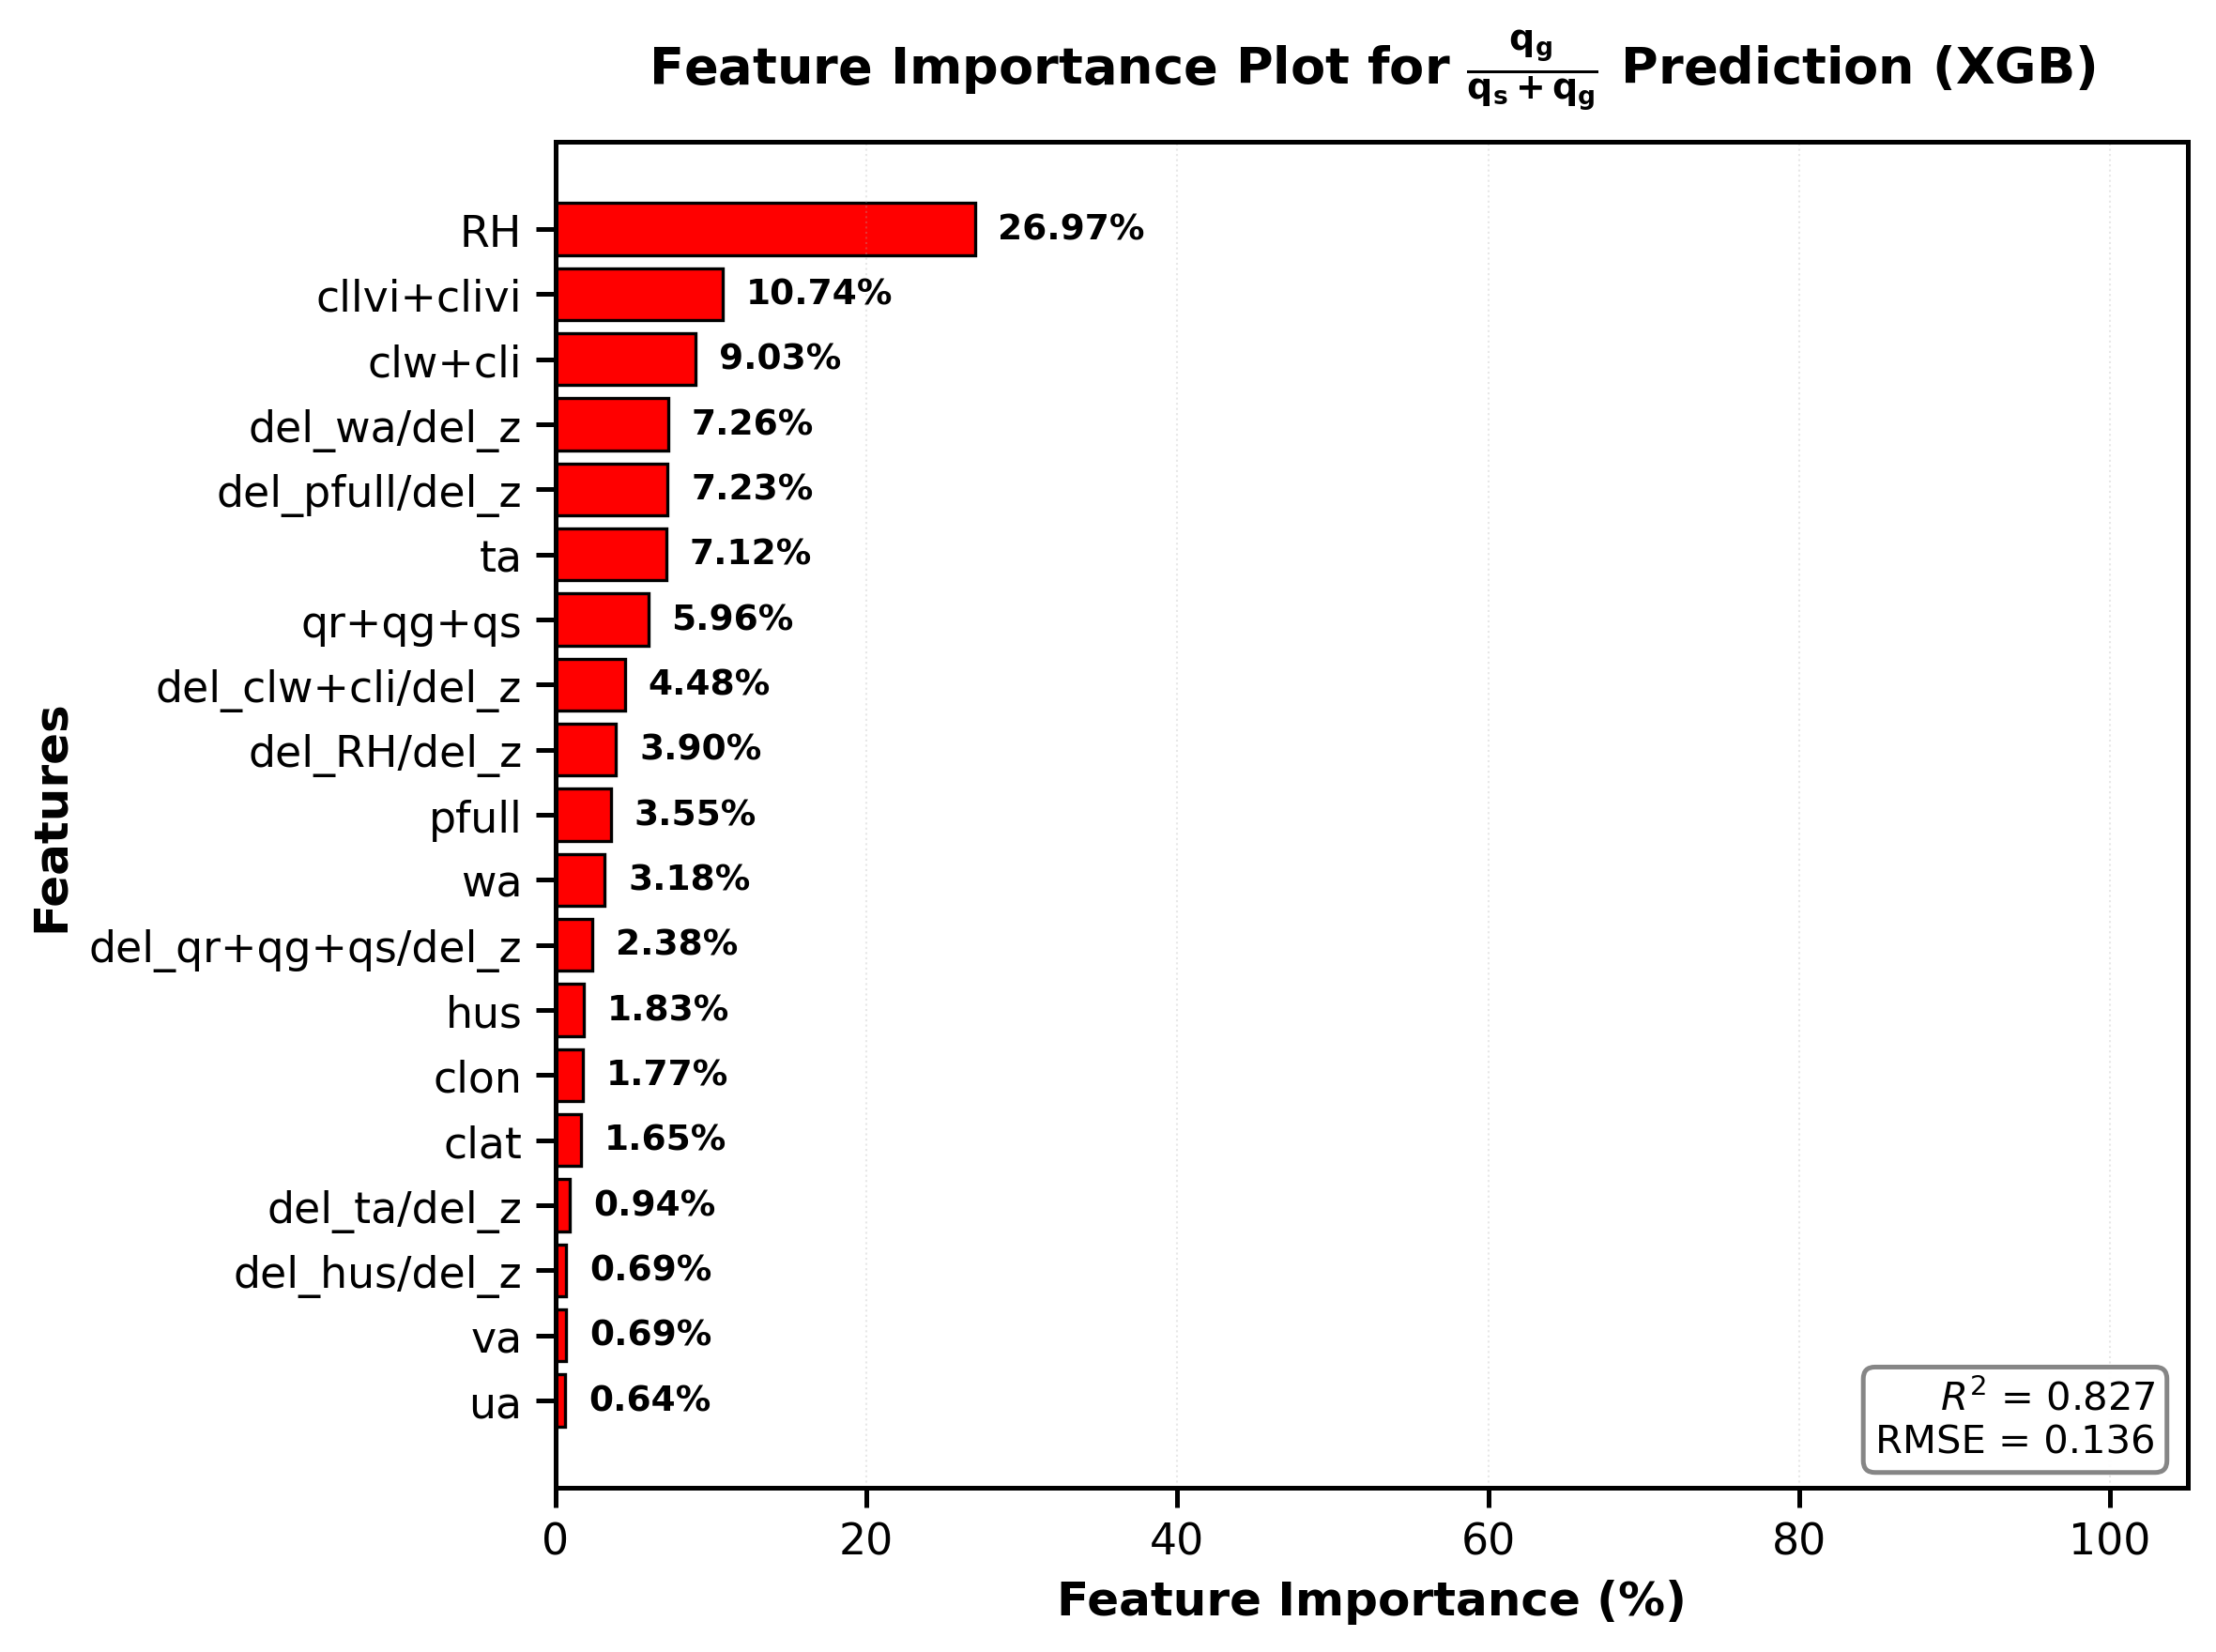

In [114]:
# Configure publication-quality parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5

# Extract feature importance
importance = model.feature_importances_

# Combine feature names and scores
feature_scores = list(zip(feature_names, importance))

# Sort by score in descending order
feature_scores.sort(key=lambda x: x[1], reverse=True)

# Convert to percentages
names = []
importances = []

for name, score in feature_scores:
    pct = score * 100
    names.append(name)
    importances.append(pct)
    print(f"{name}: {pct:.4f} %")

# Create figure with higher DPI
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Create horizontal bar plot with original red color
bars = ax.barh(names, importances, color='red', edgecolor='black', linewidth=0.8)

# Configure axes and labels
ax.set_xlabel("Feature Importance (%)", fontsize=12, fontweight='bold')
ax.set_ylabel("Features", fontsize=12, fontweight='bold')
# ax.set_title(r"XGBoost Feature Importance: Ice-Phase Hydrometeor Fraction $\mathbf{\left(\frac{q_g}{q_s + q_g}\right)}$", 
ax.set_title(r"Feature Importance Plot for $\mathbf{\frac{q_g}{q_s + q_g}}$ Prediction (XGB)", 
             fontsize=13, fontweight='bold', pad=15)

# Invert y-axis to place highest importance at the top
ax.invert_yaxis()

# Add percentage labels on bars
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    ax.text(
        width + 1.5,
        y,
        f"{width:.2f}%",
        va="center",
        fontsize=9,
        fontweight='bold'
    )

# Set x-axis range with slight padding
ax.set_xlim(0, 105)

# Add grid for enhanced readability
ax.grid(True, axis='x', alpha=0.3, linestyle=':', linewidth=0.5, zorder=0)

# Create legend text with model performance metrics
legend_text = f'$R^2$ = {r2_sklearn:.3f}\nRMSE = {rmse_TEST:.3f}'
props = dict(boxstyle='round', facecolor='white', alpha=0.95, 
             edgecolor='gray', linewidth=1.2)
ax.text(0.98, 0.02, legend_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='bottom', horizontalalignment='right',
        bbox=props)

# Ensure optimal layout
plt.tight_layout()

file_name = "output/Feature Importance Plot (with derivatives) for Prediction of qg over (qs+qg) using XGB"
plt.savefig(f"{file_name}.png", dpi=300, bbox_inches='tight')
plt.show()

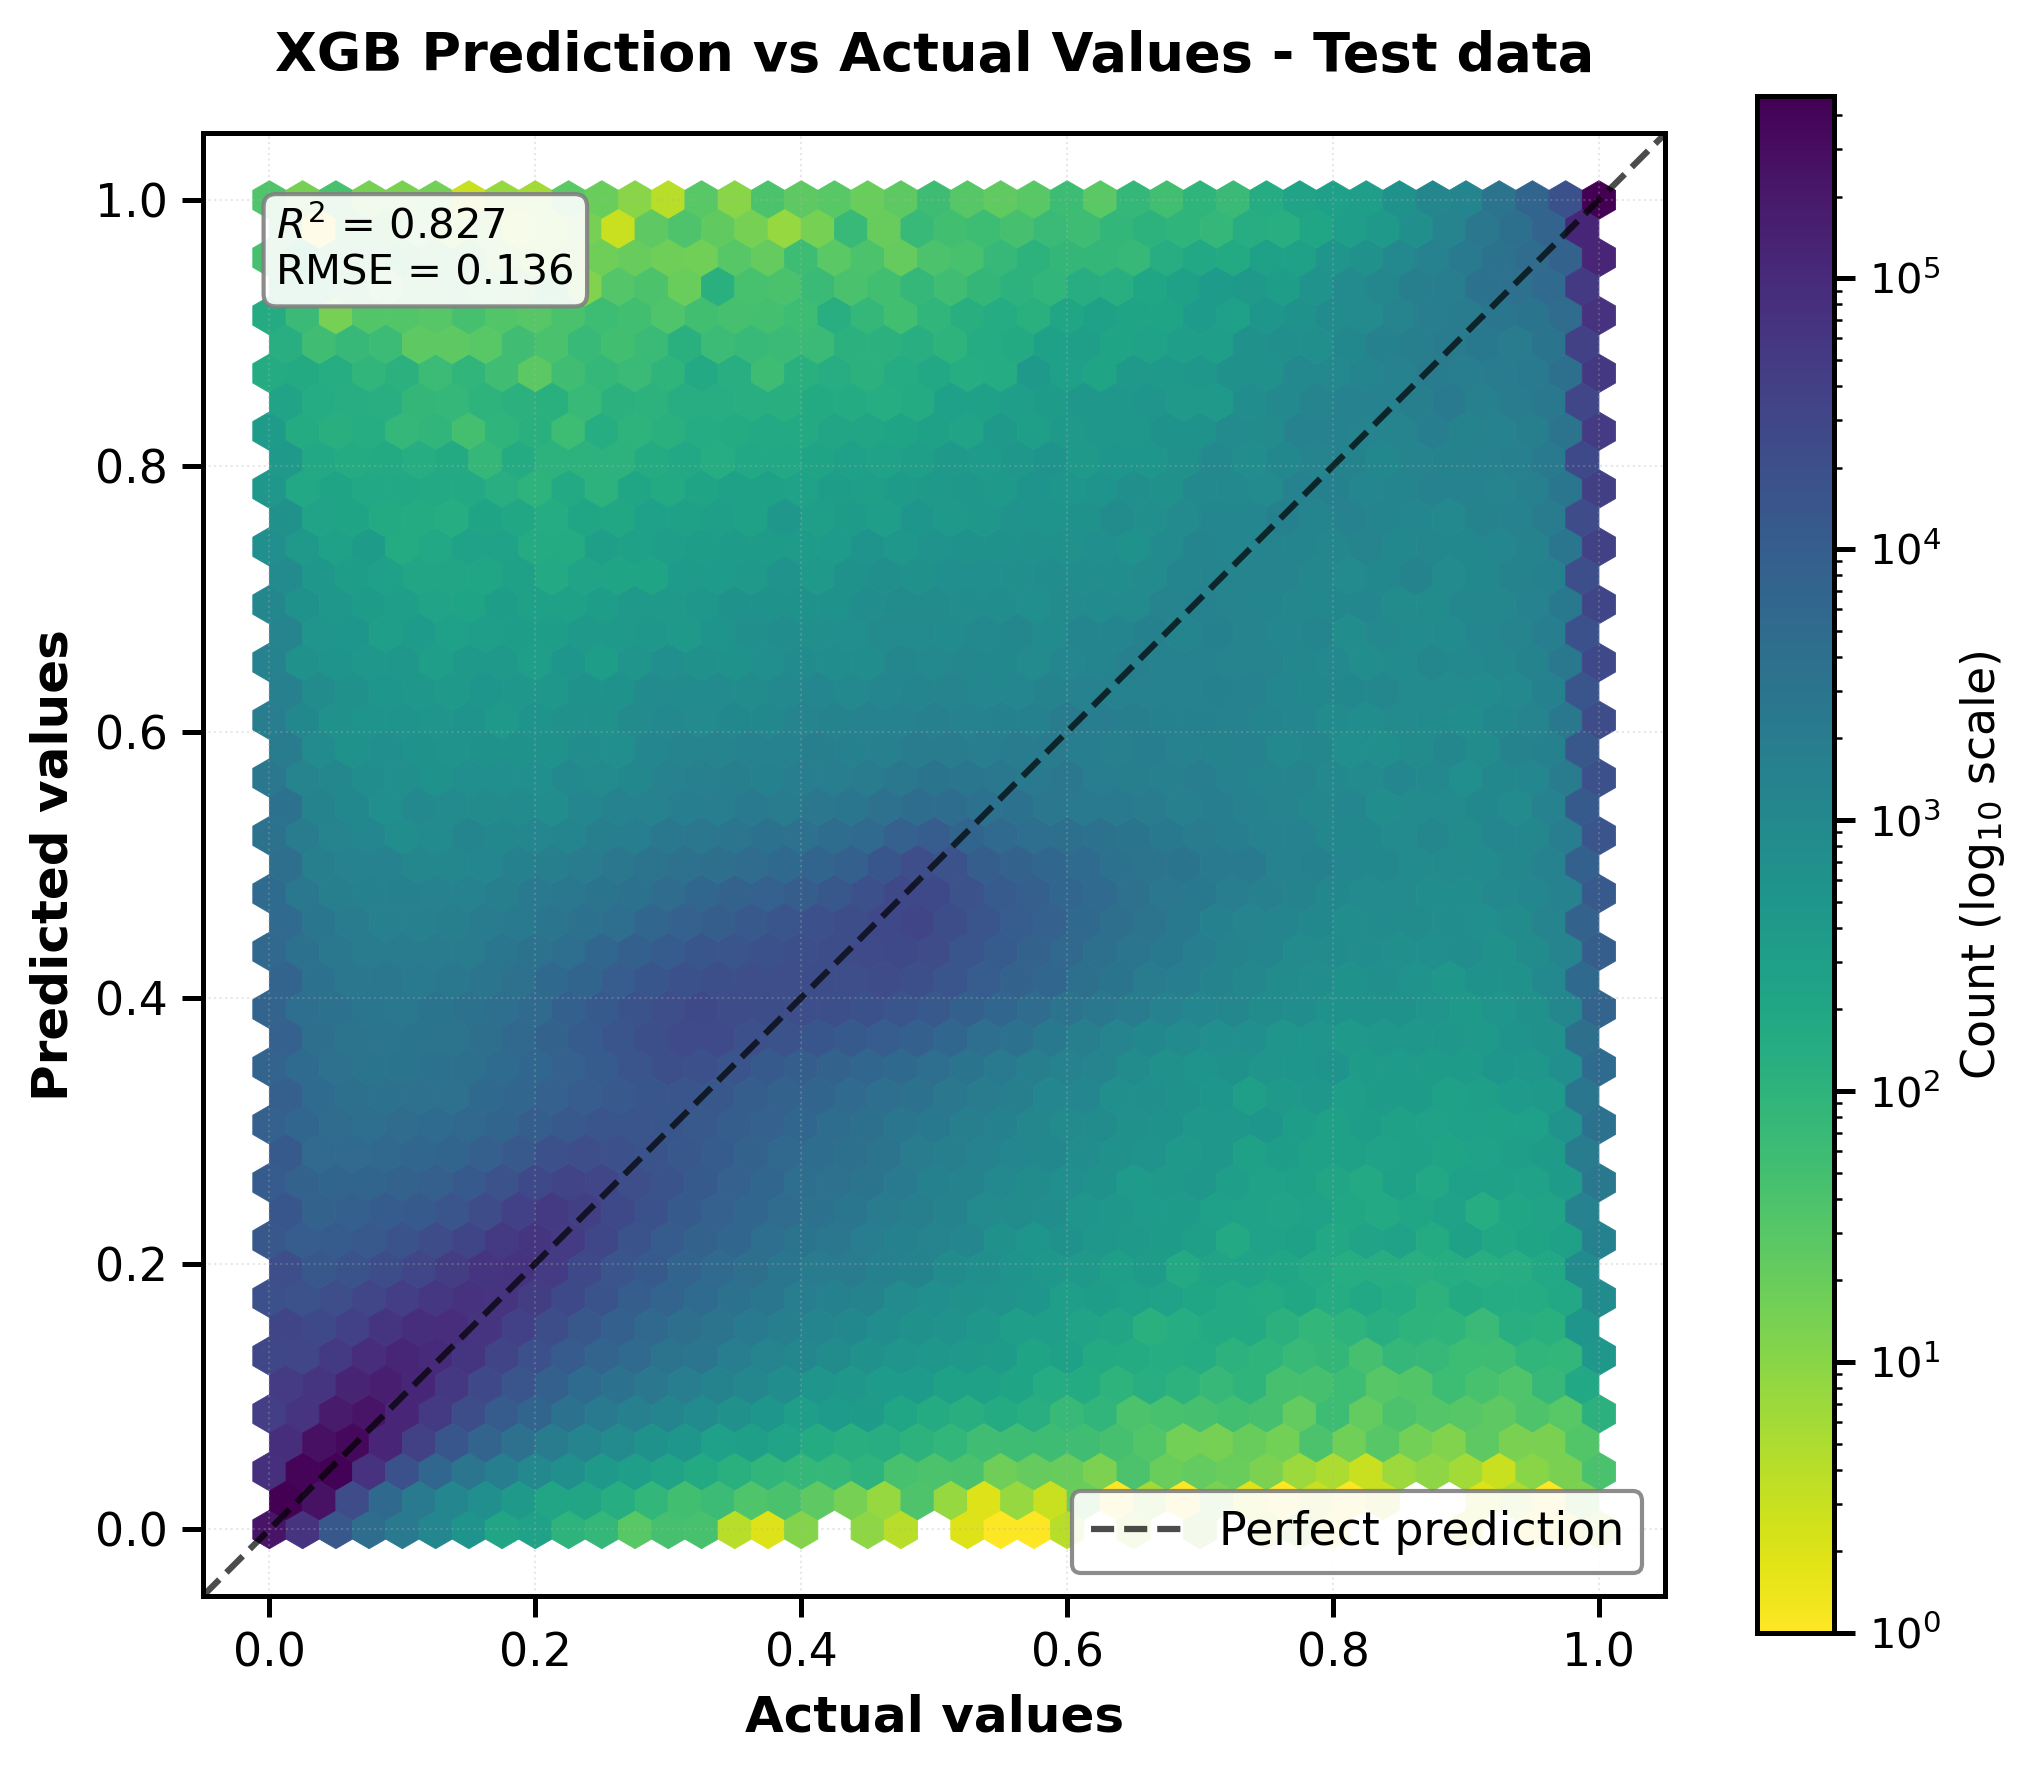

In [115]:
from matplotlib.ticker import MaxNLocator

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5

fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

# Create hexbin plot with reversed colormap (light to dark)
# Using viridis_r for reversed viridis, or try 'YlOrRd' for yellow-orange-red
hb = ax.hexbin(
    y_test.flatten(), 
    y_pred.flatten(), 
    gridsize=40,
    cmap='viridis_r',  # Reversed: dark (low) to bright yellow (high)
    bins='log',
    mincnt=1,
    linewidths=0.2,
    edgecolors='face'
)

# Add colorbar with proper formatting
cbar = plt.colorbar(hb, ax=ax, label='Count (log$_{10}$ scale)')
cbar.ax.tick_params(labelsize=10)

# Calculate axis limits with padding
data_min = min(y_test.min(), y_pred.min())
data_max = max(y_test.max(), y_pred.max())
padding = (data_max - data_min) * 0.05
ax.set_xlim(data_min - padding, data_max + padding)
ax.set_ylim(data_min - padding, data_max + padding)

# Plot perfect prediction line
ax.plot(
    [data_min - padding, data_max + padding],
    [data_min - padding, data_max + padding],
    'k--',  # Black dashed line
    lw=1.5,
    alpha=0.7,
    label='Perfect prediction',
    zorder=3
)

# Add statistics text box
textstr = f'$R^2$ = {r2_sklearn:.3f}\nRMSE = {rmse_TEST:.3f}'
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray', linewidth=1)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

# Labels and title
ax.set_xlabel('Actual values', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted values', fontsize=12, fontweight='bold')
ax.set_title('XGB Prediction vs Actual Values - Test data', fontsize=13, fontweight='bold', pad=15)

# Make axes equal and square
ax.set_aspect('equal', adjustable='box')

# Add grid for easier reading
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5, zorder=0)

# Add legend
ax.legend(loc='lower right', framealpha=0.9, edgecolor='gray')

# Ensure layout fits
plt.tight_layout()
plt.show()

# Alternative colormaps to try:
# 'viridis_r' - reversed viridis (dark purple to bright yellow)
# 'YlOrRd' - light yellow to dark red (intuitive: light=few, dark=many)
# 'Blues' - light to dark blue
# 'Reds' - light to dark red
# 'plasma_r' - reversed plasma (dark to bright yellow)
# 'magma_r' - reversed magma (dark to bright yellow/white)

In [116]:
overall_end_time = time.time()
totalElapsedTime=overall_end_time - overall_start_time
print(f"The Total Elapsed Time is: {totalElapsedTime/60:.4f} minutes")

The Total Elapsed Time is: 15.0720 minutes
